In [1]:
import pandas as pd
df = pd.read_csv("../data/tickets.csv")
print(df.shape)             
# (rows, columns)
print(df.columns.tolist())
df.head()

(28587, 16)
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [2]:
df = df[df["language"] == "en"].copy()
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df = df[["text", "queue"]].dropna().drop_duplicates()
df = df[df["text"].str.strip().str.len() > 10]   # drop near-empty tickets
print(df.shape)

(16338, 2)


queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64


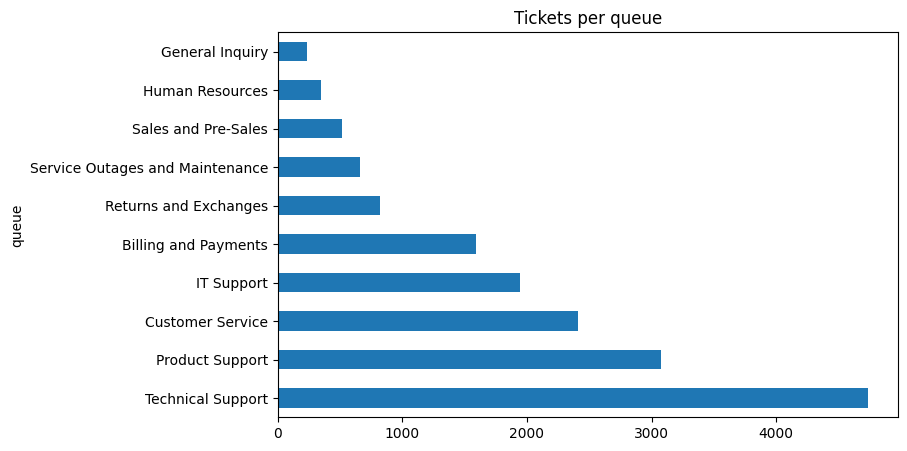

In [3]:
import matplotlib.pyplot as plt
counts = df["queue"].value_counts()
print(counts)
counts.plot(kind="barh", figsize=(8, 5), title="Tickets per queue"); 
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
keep = counts[counts >= 50].index
df = df[df["queue"].isin(keep)]
X_train, X_test, y_train, y_test = train_test_split(
df["text"], df["queue"], test_size=0.2, stratify=df["queue"], 
random_state=42)
print(len(X_train), len(X_test))

13070 3268
